# Unsupervised Learning

In this field, we work with unlabeled data. While in supervised learning we try to generalize the data based on given target data, in unsupervised learning we create our own labels.

## Clustering

Cluster - group of nearly placed instances

### K-means

This algorithm works by defining centroids of clusters.


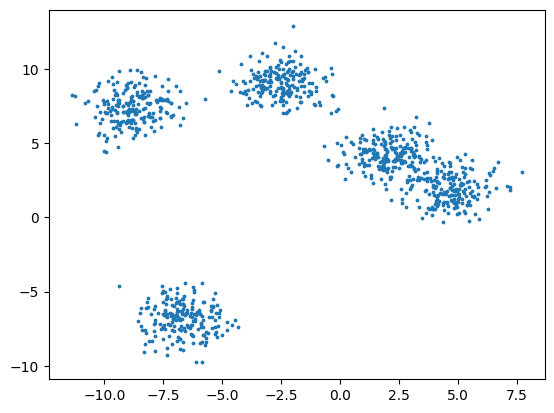

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=5, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=3)
plt.show()

In [2]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
kmeans.labels_[:10]

array([4, 4, 0, 4, 1, 0, 3, 1, 4, 1], dtype=int32)

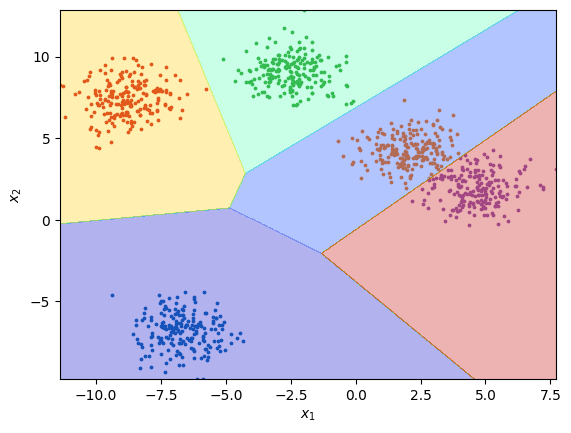

In [3]:
import numpy as np

def plot_2d_scatter_and_centers(X: np.typing.NDArray, kmeans: KMeans, resolution: int = 1000,  centers: np.typing.NDArray | None = None) -> None:
    for i in range(k):
        plt.scatter(X[:, 0][y_pred == i], X[:, 1][y_pred == i], s=3)

    X_mins = X.min(axis=0)
    X_maxs = X.max(axis=0)


    xx, yy = np.meshgrid(
        np.linspace(X_mins[0], X_maxs[0], resolution),
        np.linspace(X_mins[1], X_maxs[1], resolution)
    )

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, alpha=0.3, extent=(X_mins[0], X_maxs[0], X_mins[1], X_maxs[1]), cmap="jet")

    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], marker="*", s=100, c="black")

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")

    plt.show()

plot_2d_scatter_and_centers(X, kmeans)

In [4]:
kmeans.cluster_centers_

array([[-6.68630691, -6.81139455],
       [ 2.03639615,  4.26762858],
       [-2.50265159,  9.03963769],
       [-8.80798056,  7.40425704],
       [ 4.66534309,  1.87476184]])

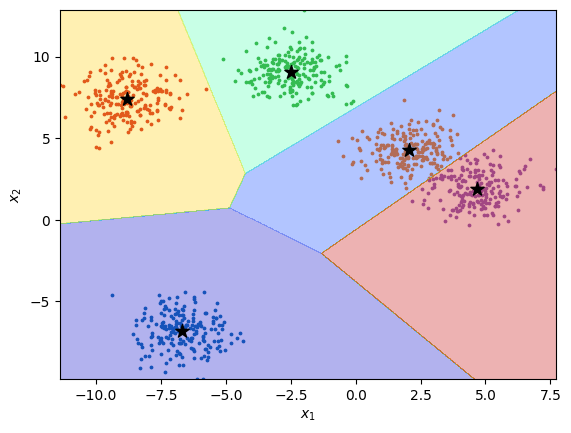

In [5]:
plot_2d_scatter_and_centers(X, kmeans, 1000, kmeans.cluster_centers_)

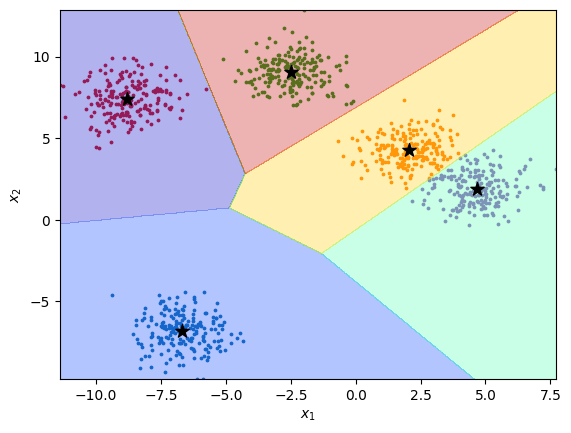

In [6]:
good_inits = np.array([
    [-8.5, 7],
    [-7.5, -6],
    [5, 0.5],
    [2.3, 4],
    [-2.3, 8.5]

])

kmeans = KMeans(n_clusters=5, init=good_inits, n_init=1)
kmeans.fit(X)
plot_2d_scatter_and_centers(X, kmeans, centers=kmeans.cluster_centers_)

In [7]:
kmeans.inertia_

1873.4290193066272

## Mini-Batch K-means

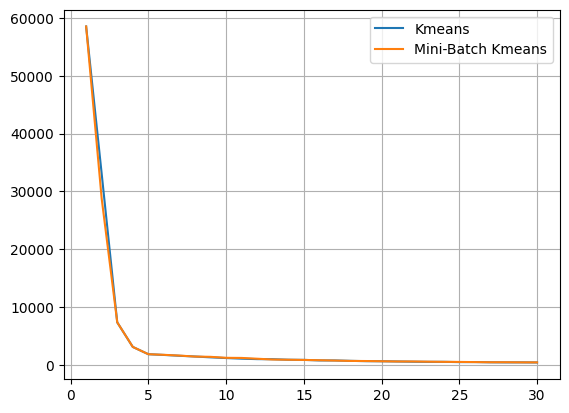

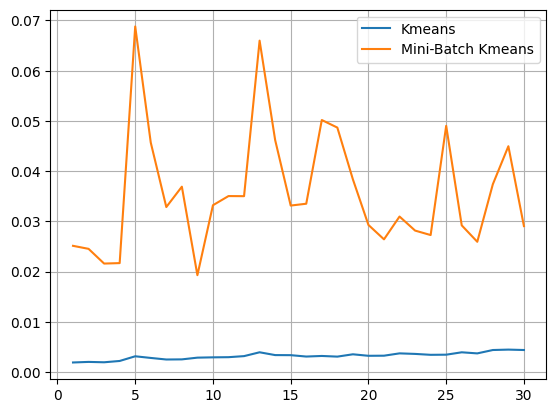

In [8]:
from sklearn.cluster import MiniBatchKMeans
import time

def plot_ks_inertia(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    

    kmeans_plot_inertia = []
    kmeans_batch_plot_inertia = []

    for k_ in range(skip_starting_k+1, k+1):
        kmeans_batch = MiniBatchKMeans(n_clusters=k_).fit(X)
        kmeans = KMeans(n_clusters=k_).fit(X)

        kmeans_plot_inertia.append(kmeans.inertia_)
        kmeans_batch_plot_inertia.append(kmeans_batch.inertia_)
    
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_plot_inertia, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_plot_inertia, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

def plot_ks_training_time(k: int, X: np.typing.NDArray, skip_starting_k: int = 0) -> None:
    if skip_starting_k < 0:
        raise ValueError("You can't skip negative amount of instances")
    
    kmeans_time = []
    kmeans_batch_time = []

    for k_ in range(skip_starting_k+1, k+1):
        start = time.perf_counter()
        MiniBatchKMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()
        
        kmeans_batch_time.append(end - start)

        start = time.perf_counter()
        KMeans(n_clusters=k_, n_init=1).fit(X)
        end = time.perf_counter()

        kmeans_time.append(end - start)

    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_time, label="Kmeans")
    plt.plot(np.arange(skip_starting_k+1, k+1), kmeans_batch_time, label="Mini-Batch Kmeans")

    plt.legend()
    plt.grid(True)
    plt.show()

plot_ks_inertia(k=30, X=X, skip_starting_k=0)
plot_ks_training_time(k=30, X=X, skip_starting_k=0)

## Clustering for Image Segmentation

Using clustering, we can assign each pixel to it's cluster using k-means to reduce number of colors in image.

In [9]:
import PIL

image = np.asarray(PIL.Image.open("pictures/serenity.png"))
image.shape

(600, 800, 3)

Dimensions are height, width and RGB color chanels.

Matplotlib could handle it, let's draw the image

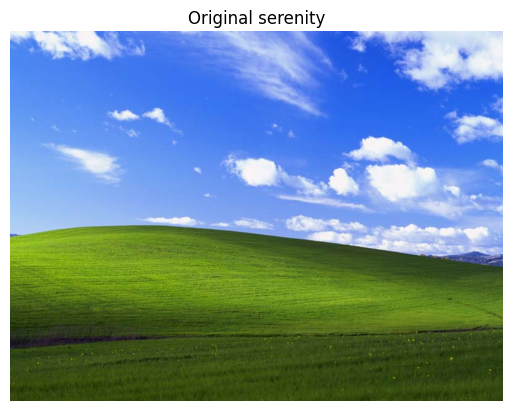

In [10]:
plt.imshow(image.astype(int))
plt.axis("off")
plt.title("Original serenity")
plt.show()

Now we need to get every pixel and it's color chanells as a matrix

In [11]:
X = image.reshape(-1, 3)
X.shape

(480000, 3)

And now, we can apply Kmeans, and replace each pixel with center of it's following centroid.

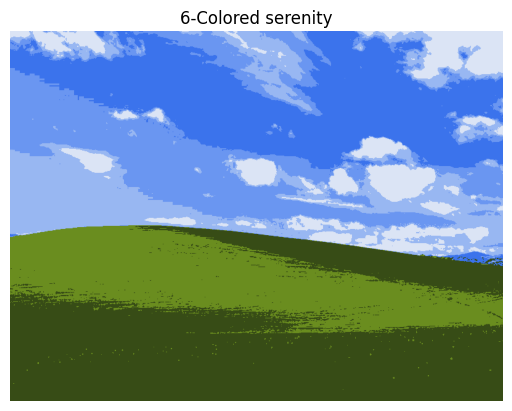

In [12]:
n_colors = 6

kmeans = KMeans(n_clusters=n_colors).fit(X)
segmented_image = kmeans.cluster_centers_[kmeans.labels_]
segmented_image = segmented_image.reshape(image.shape)

plt.imshow(segmented_image.astype(int))
plt.axis("off")
plt.title(f"{n_colors}-Colored serenity")
plt.show()

## Clustering for Semi-Supervised Learning (Label-Propagation)



We can use clustering for lable propagarion. In case when we don't have sufficient number of labels per instance in the dataset.

Let's load MNIST-like dataset for an example.

In [13]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)

X_digits_train, y_digits_train = X_digits[:1400], y_digits[:1400]
X_digits_test, y_digits_test = X_digits[1400:], y_digits[1400:]

Let't pretend that we have only 50 labeled instances, and train **Logistic Regression**

In [14]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(penalty="l2", max_iter=10_000, random_state=42)
lg = lg.fit(X_digits_train[:50], y_digits_train[:50])

In [15]:
lg.score(X_digits_test, y_digits_test)

0.7581863979848866

As you can see, accuracy is terrible. If we trained the model on the full dataset, we would achieve $90\%$ score.

We can try two ways to improve the model's performance.
We can cluster the dataset into $50$ clusters, then, for each cluster, we'll find image that is closest to the centroid. This is called - representative images.

In [16]:
k = 50
kmeans = KMeans(k, random_state=42)
X_digits_distance_space = kmeans.fit_transform(X_digits_train)
representative_digits_idx = np.argmin(X_digits_distance_space, axis=0)
X_representative_digits = X_digits_train[representative_digits_idx]

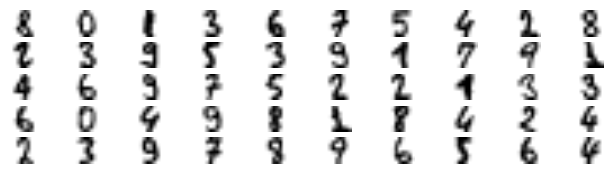

In [17]:
plt.figure(figsize=(8, 2))
for index, representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

Now we have digits that represent our dataset better than random chosen labels. 
Let's manually label them and and see whether our 50-label classifier performance would improve

In [18]:
y_representative_digits = np.array([
    8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4
]) # manually labeled
lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_representative_digits, y_representative_digits)
lg.score(X_digits_test, y_digits_test)

0.8337531486146096

Much better than was before!

We can take a one step further. And **propagate** those labels to all other instance of the training set in its corresponding cluster.

In [19]:
y_train_propagated = np.empty(len(X_digits_train), dtype=np.int64)
for i in range(len(y_representative_digits)):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

Let's see the results...

In [20]:
lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_digits_train, y_train_propagated)
lg.score(X_digits_test, y_digits_test)

0.8690176322418136

A little better! 
We can try to improve the results even more. Like ignoring instances that are farthest from theirs cluster.

In [21]:
percentile_closest = 99

X_cluster_dist = X_digits_distance_space[np.arange(len(X_digits_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_digits_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [22]:
print(f"Lost {len(X_digits_train) - len(X_train_partially_propagated)} entries")

lg = LogisticRegression(penalty="l2", random_state=42, max_iter=1_000)
lg.fit(X_train_partially_propagated, y_train_partially_propagated)
print(f"Accuracy - {np.round(lg.score(X_digits_test, y_digits_test), 2)}")

print(f"Propagated labels accuracy: {(y_train_partially_propagated == y_digits_train[y_train_partially_propagated]).mean()}")

Lost 50 entries
Accuracy - 0.86
Propagated labels accuracy: 1.0


We didn't get better results, as was expected. But, you got the idea. Maybe the issue is bad manual labeling.

### DBSCAN

Another clustering algorithm that is capable of working with more complex clusters.

In [23]:
def plot_dbscan_clusters(X, y_predicted, eps: float, min_samples: int):
    """Takes results of fit_predict() DBSCAN method"""

    # plot clusters including anomalies cluster
    for cluster in np.unique(y_predicted):
        alpha = 0.3
        size = 30
        if cluster == -1:
            alpha = 1.0
            size = 50
            marker = "x" # cross marker
        else:
            marker = None

        mask = y_predicted == cluster

        X_cluster = X[mask, :]
        plt.scatter(X_cluster[:, 0], X_cluster[:, 1], s=size, alpha=alpha, marker=marker)

        # draw epsilon region
        plt.scatter(X_cluster[:, 0], X_cluster[:, 1], s=1_000 * eps, alpha=0.05, c='grey')

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(fr"DBSCAN on make_moons, $\epsilon={eps}$, min_samples=${min_samples}$ (eps region size is estimated)")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()


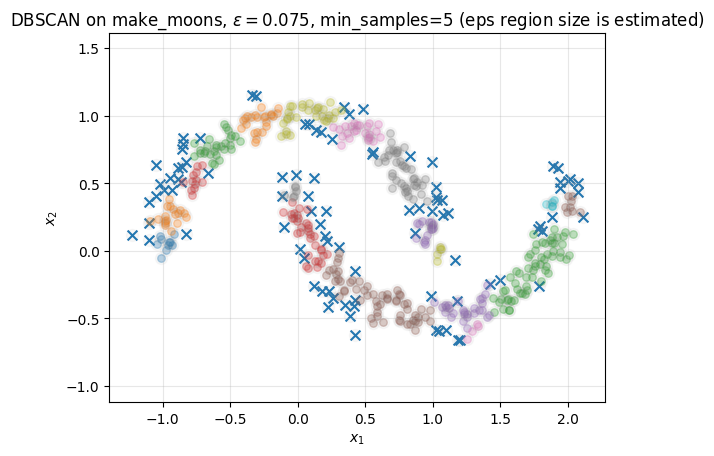

In [24]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.08)

dbscan = DBSCAN(eps=0.075, min_samples=5)
y_predicted = dbscan.fit_predict(X, y)

plot_dbscan_clusters(X, y_predicted, dbscan.eps, dbscan.min_samples)

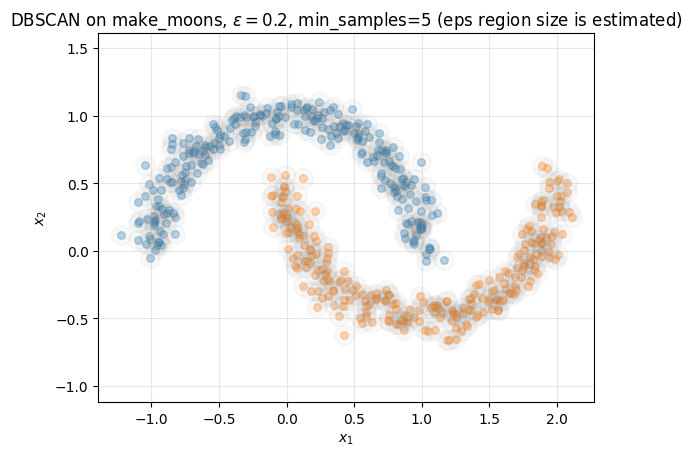

In [25]:
dbscan = DBSCAN(eps=0.20, min_samples=5)
y_predicted = dbscan.fit_predict(X, y)

plot_dbscan_clusters(X, y_predicted, dbscan.eps, dbscan.min_samples)

In [26]:
print(f"Core instances (doesn't include anomalies): {dbscan.components_[:10]}")
print(f"Theis indeces: {dbscan.core_sample_indices_[:10]}")

Core instances (doesn't include anomalies): [[-1.83420907e-01  9.93940947e-01]
 [ 1.42289154e+00 -2.44355196e-01]
 [ 7.00776909e-01  5.78326726e-01]
 [ 1.18327233e+00 -6.57777937e-01]
 [ 4.80291271e-01  1.04715078e+00]
 [-2.36323667e-01  9.26529088e-01]
 [ 1.88529214e+00 -5.58753329e-04]
 [-1.10325452e+00  3.63033191e-01]
 [ 1.82999543e+00 -1.44466657e-01]
 [-5.36949405e-02  1.07467905e+00]]
Theis indeces: [0 1 2 3 4 5 6 7 8 9]


### Gaussian Mixtures

In [27]:
def plot_2d_blobs(X, figsize=(6, 6), s=10, alpha=0.6, color='C0', marker='o', title=None, show=True):
    """
    Plot 2D blobs (scatter) without labels.
    X: array-like with shape (n_samples, >=2). Uses first two columns.
    """
    X = np.asarray(X)
    
    plt.figure(figsize=figsize)
    plt.scatter(X[:, 0], X[:, 1], s=s, alpha=alpha, c=color, marker=marker)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")

    if title:
        plt.title(title)
    if show:
        plt.show()


[[ 4.00912155  1.22031802]
 [ 7.92863355 -8.00631448]
 [-7.03355715 -5.38035724]]
[0.33330152 0.33329848 0.3334    ]
[[[ 1.40086733 -0.02687088]
  [-0.02687088  1.41603779]]

 [[ 1.45122957  0.00859305]
  [ 0.00859305  1.36685648]]

 [[ 1.46050636 -0.02980239]
  [-0.02980239  1.44374106]]]


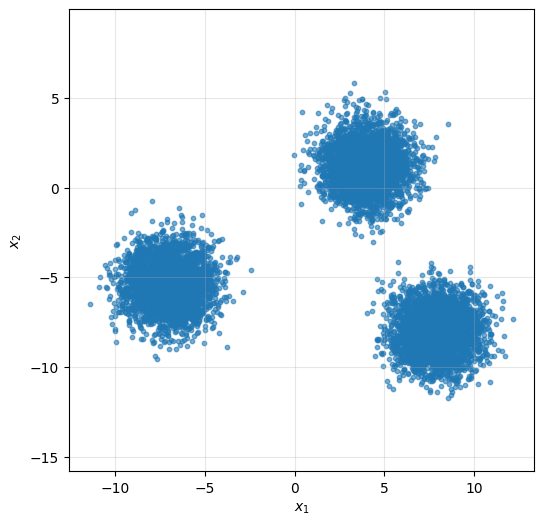

In [28]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=10_000, centers=3, cluster_std=1.2)

gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

print(gm.means_)
print(gm.weights_)
print(gm.covariances_)
plot_2d_blobs(X)

In [29]:
print(gm.converged_)
print(gm.n_iter_)

True
2


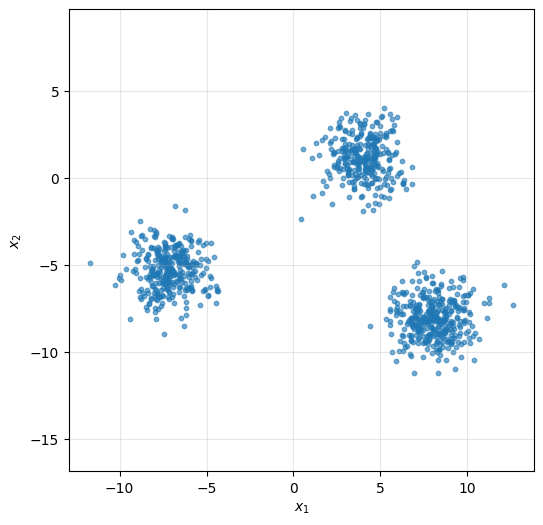

In [30]:
X_new, y_new = gm.sample(1000)
plot_2d_blobs(X_new)

# Exercises

1. How would you define clustering? Can you name a few clustering algorithms?

> I would define clustering as an unsupervised-learning task where we're trying to join data instances into groups which we call clusters. Basically, we're trying to figure out the missing labels. Clustering algorithms: K-means, DBSCAN, GMM.

2. What are some of the main applications of clustering algorithms?

> Anomaly detection, novelty detection, image segmentation, semi-supervised learning, data-analysis

3. Describe two techniques to select the right number of clusters when using k-means.

> You can use either inertia or silhouette coefficient _(requires more computing power)_. But ilhouette coefficient will give you more precise view, because inertia considers only density of clusters.

4. What is label propagation? Why would you implement it, and how?

> Imagine a case when we don't have labels and it's to expensive to label the data by hand. We can use clustering algorithms to choose the k most representative instances, manually assign labels (assuming that you're not blind), and propagate labels to corresponding instances inside the clusters. Voila, we got a labeled dataset.

5. Can you name two clustering algorithms that can scale to large datasets? And two that look for regions of hign density?

> Algorithms that scale to large datasets are K-means and BIRCH. Algorithms that look for high-density regsions are DBSCAN and GMM.

6. Can you think of a use case where active learning would be useful. How would you implement it?

> In cases when we have datasets with no or little number of labels. When we're manually labeling instances in which models is unsure about we provide lot's of new information effectively. I would implement it that way: I would use clustering model that supports predict_proba() method to evaluate instances that the models is unsure about. Then train the model on manualy labeled instances and run predictions of the rest of the databaset. Then I would choose a probability threshold and manually label them and iterate over this process again.

7. What is the difference between anomaly and novelty detection?

> In anomaly detection you train a model on a whole dataset which includes outliers. But in novelty detection you consider starting dataset with no outliers, and subsequent instances that would would differ from known clusters would be considered as novelty.

8. What is a Gaussian Mixture? What tasks can you use it for?

> Gaussian mixture expects that a dataset consists only with gaussian distribution shaped clusters (speherical, elipsoid). To use this model you need to know number of clusters.

9. Can you name two techniques to find the right number of custers when using a Gaussian Mixture model?

> BIC and AIC

10. The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of faces. Each image is flattened to a 1D vector of size 4,096. 40 different people were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture.
Load the dataset using the `sklearn.datasets.fetch_olivetti_faces()` function, then split it into a training set, a validation set, and a test set (note that the dataset is already scaled between 0 and 1). Since the dataset is quite small, you probably want to use stratified sampling to ensure that there are the same number of images per person in each set.
Next, cluster the images using K-Means, and ensure that you have a good number of clusters (using one of the techniques discussed in this chapter). Visualize the clusters: do you see similar faces in each cluster?


Fetch the Olivetti dataset

In [31]:
from sklearn.datasets import fetch_olivetti_faces

X, y = fetch_olivetti_faces(return_X_y=True)
print(f"Source data shape: {X.shape}")
print(f"N-true clusters: {len(np.unique(y))}")

Source data shape: (400, 4096)
N-true clusters: 40


Split the dataset usign stratified splitting _(since each cluster consists of 10 people only)_

In [32]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2)

for train_idx, test_idx in sss.split(X, y):
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

print(f"Source data shape: {X_test.shape}")
print(f"N-true clusters: {len(np.unique(y_test))}")

Source data shape: (80, 4096)
N-true clusters: 40


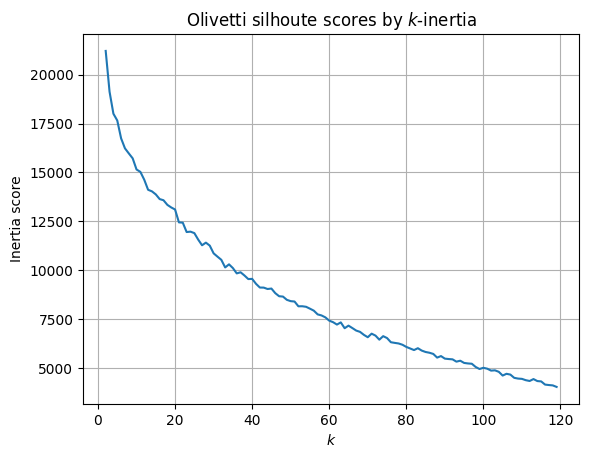

In [33]:
x_plt, y_plt = [], []

for k in range(2, 120):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_train)

    x_plt.append(k)
    y_plt.append(kmeans.inertia_)

plt.plot(x_plt, y_plt)
plt.xlabel("$k$")
plt.ylabel("Inertia score")
plt.title("Olivetti silhoute scores by $k$-inertia")
plt.grid(True)
plt.show()

In [73]:
kmeans = KMeans(n_clusters=90)
kmeans.fit(X_train)

X_cluster_1 = X_train[(kmeans.labels_ == 0)]
X_cluster_2 = X_train[(kmeans.labels_ == 1)]
X_cluster_3 = X_train[(kmeans.labels_ == 1)]


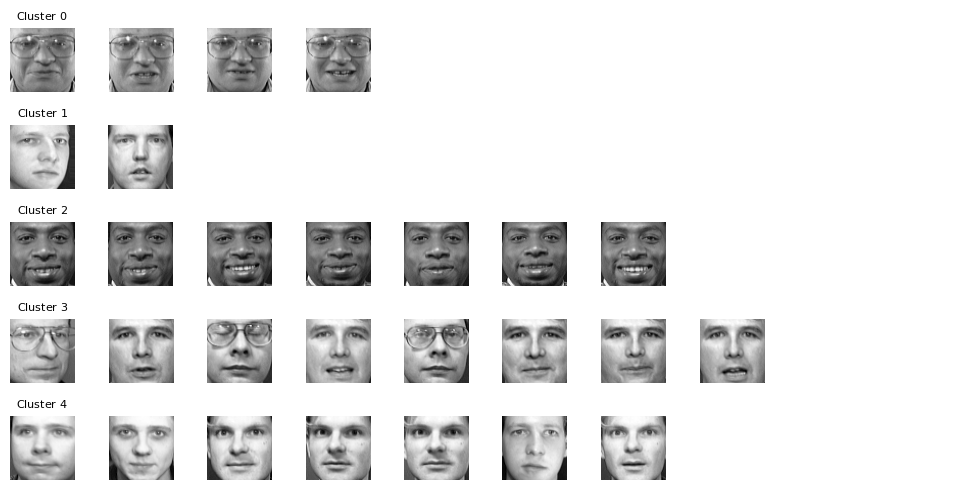

<Figure size 640x480 with 0 Axes>

In [74]:
X_cluster_1 = X_train[kmeans.labels_ == 0]
X_cluster_2 = X_train[kmeans.labels_ == 1]
X_cluster_3 = X_train[kmeans.labels_ == 2]
X_cluster_4 = X_train[kmeans.labels_ == 3]
X_cluster_5 = X_train[kmeans.labels_ == 4]

clusters = [
    X_cluster_1, X_cluster_2, X_cluster_3, X_cluster_4, X_cluster_5
]

fig, axes = plt.subplots(len(clusters), 10, figsize=(10, 5))

for row, X_cluster in enumerate(clusters):
    axes[row, 0].set_title(f"Cluster ${row}$", loc="center", fontsize=8)
    for col in range(10):
        if col < len(X_cluster):
            axes[row, col].imshow(X_cluster[col].reshape(64, 64), cmap="gray")
            axes[row, col].axis("off")
        else:
            axes[row, col].axis("off")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

11. Continuing with the Olivetti faces dataset, train a classifier to predict which person is represented in each picture, and evaluate it on the validation set. Next, use K-Means as a dimensionality reduction tool, and train a classifier on the reduced set. Search for the number of clusters that allows the classifier to get the best performance: what performance can you reach? What if you append the features from the reduced set to the original features (again, searching for the best number of clusters)?

In [75]:
from sklearn.svm import SVC

lg = SVC()
lg.fit(X_train, y_train)

print(f"Accuracy score: {lg.score(X_test, y_test)}")

Accuracy score: 0.925


In [76]:
kmeans = KMeans(n_clusters=90)
X_train_reduced = kmeans.fit_transform(X_train)
X_test_reduced = kmeans.transform(X_test)
print(f"Reduced shape: {X_train_reduced.shape}")

Reduced shape: (320, 90)


In [77]:
lg = SVC()
lg.fit(X_train_reduced, y_train)

print(f"Accuracy score: {lg.score(X_test_reduced, y_test)}")

Accuracy score: 0.6875


In [78]:
from sklearn.pipeline import make_pipeline
for n_clusters in range(20, 81):
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, n_init=10, random_state=42),
        SVC()
    )
    pipeline.fit(X_train, y_train)
    print(n_clusters, pipeline.score(X_test, y_test))


20 0.65
21 0.6375
22 0.6625
23 0.675
24 0.6875
25 0.65
26 0.6625
27 0.6625
28 0.6375
29 0.675
30 0.6625
31 0.675
32 0.6875
33 0.6625
34 0.6625
35 0.675
36 0.6875
37 0.6625
38 0.675
39 0.6875
40 0.675
41 0.675
42 0.7125
43 0.6875
44 0.7
45 0.675
46 0.675
47 0.6625
48 0.7125
49 0.6625
50 0.675
51 0.675
52 0.6625
53 0.6875
54 0.7
55 0.7125
56 0.7125
57 0.7
58 0.7
59 0.7
60 0.675
61 0.6875
62 0.6875
63 0.7125
64 0.7125
65 0.7125
66 0.7125
67 0.6875
68 0.675
69 0.675
70 0.7125
71 0.7125
72 0.725
73 0.7
74 0.725
75 0.7
76 0.725
77 0.7125
78 0.7
79 0.7375
80 0.7


12. Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the algorithm, you should probably reduce the dataset's dimensionality (e.g., use PCA, preserving 99% of the variance). Use the model to generate some new faces (using the `sample()` method), and visualize them (if you used PCA, you will need to use its `inverse_transform()` method). Try to modify some images (e.g., rotate, flip, darken) and see if the model can detect the anomalies (i.e., compare the output of the `score_samples()` method for normal images and for anomalies).


13. Some dimensionality reduction techniques can also be used for anomaly detection. For example, take the Olivetti faces dataset and reduce it with PCA, preserving 99% of the variance. Then compute the reconstruction error for each image. Next, take some of the modified images you built in the previous exercise, and look at their reconstruction error: notice how much larger the reconstruction error is. If you plot a reconstructed image, you will see why: it tries to reconstruct a normal face.